In [1]:


import warnings
warnings.filterwarnings('ignore')


from functools import partial


import torch
import torch.nn as nn

import torch.nn.functional as F


In [2]:


class VQ(nn.Module):
    
    def __init__(self, num_embeddings=512, embedding_dim=64, commitment_cost=0.25):
        super().__init__()

        # 嵌入的数量，通常是离散化的向量数量
        self.num_embeddings = num_embeddings
        # 嵌入向量的维度
        self.embedding_dim = embedding_dim
        # 承诺损失的权重，用于平衡量化损失和重构损失
        self.commitment_cost = commitment_cost
        
        # 初始化嵌入层，创建 num_embeddings 个 embedding_dim 维的嵌入向量
        self.embeddings = nn.Embedding(self.num_embeddings, self.embedding_dim)
        # 将嵌入权重初始化为均匀分布
        self.embeddings.weight.data.uniform_(-1/self.num_embeddings, 1/self.num_embeddings)
    
    def forward(self, inputs):
        # 将输入的形状从 (batch_size, channels, height, width) 转换为 (batch_size, height, width, channels)
        inputs = inputs.permute(0, 2, 3, 1).contiguous()
        input_shape = inputs.shape
        
        # 将输入展平为二维张量，以便计算距离
        flat_inputs = inputs.view(-1, self.embedding_dim)
        
        # 计算输入与嵌入向量之间的距离
        distances = torch.cdist(flat_inputs, self.embeddings.weight)
        # 找到每个输入的最近嵌入向量索引
        encoding_index = torch.argmin(distances, dim=1) 
        
        # 使用最近的嵌入向量替换输入，得到量化后的结果
        quantized = torch.index_select(self.embeddings.weight, 0, encoding_index).view(input_shape)
        
        # 计算量化损失（重构损失）
        e_latent_loss = F.mse_loss(quantized.detach(), inputs)
        # 计算承诺损失（保证输入和量化值之间的关系）
        q_latent_loss = F.mse_loss(quantized, inputs.detach())
        # 总损失是承诺损失和量化损失的加权和
        c_loss = q_latent_loss + self.commitment_cost * e_latent_loss
        
        # 使用量化值更新输入，保持梯度流动
        quantized = inputs + (quantized - inputs).detach()
        
        # 将量化后的结果形状恢复为 (batch_size, channels, height, width)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()
        return c_loss, quantized


class ResudialBlock(nn.Module):
    def __init__(self,in_channels,out_channels,hidden_channels):
        super(ResudialBlock,self).__init__()
        self.resblock = nn.Sequential(nn.ReLU(inplace=True),
                                       nn.Conv2d(in_channels,hidden_channels,kernel_size=3,stride=1,padding=1,bias=False),
                                       nn.ReLU(inplace=True),
                                       nn.Conv2d(hidden_channels,out_channels,kernel_size=1,stride=1,bias=False))
    def forward(self,x):
        return x + self.resblock(x)

class ResudialStack(nn.Module):
    def __init__(self,in_channels,out_channels,hidden_channels,num_res_layers):
        super(ResudialStack,self).__init__()
        self.num_res_layers = num_res_layers
        self.layers = nn.ModuleList([ResudialBlock(in_channels,out_channels,hidden_channels) for _ in range(num_res_layers)])
    
    def forward(self,x):
        for i in range(self.num_res_layers):
            x = self.layers[i](x)
        return F.relu(x)
    

class Model(nn.Module):

    def __init__(self,num_embeddings=512,embedding_dim=64,commitment_cost=0.25):
        super().__init__()

        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost

        #encode
        self.conv1 = nn.Conv2d(3,64,kernel_size=4,stride=2,padding=1)
        self.conv2 = nn.Conv2d(64,128,kernel_size=4,stride=2,padding=1)
        self.conv3 = nn.Conv2d(128,128,kernel_size=3,stride=1,padding=1)
        self.resblock1 = ResudialStack(128,128,64,3)
        
        #vq 
        self.vq_conv = nn.Conv2d(128,self.embedding_dim,kernel_size=1,stride=1)
        self.vq = VQ(self.num_embeddings,self.embedding_dim,self.commitment_cost)
        
        #decode
        self.conv4 = nn.Conv2d(self.embedding_dim,64,kernel_size=3,stride=1,padding=1)
        self.resblock2 = ResudialStack(64,64,32,3)
        self.conv5 = nn.ConvTranspose2d(64,32,kernel_size=4,stride=2,padding=1)
        self.conv6 = nn.ConvTranspose2d(32,3,kernel_size=4,stride=2,padding=1)


    def encode(self,x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        x = self.resblock1(x)
        return x
        
    def decode(self,quantized):
        x = self.conv4(quantized)
        x = self.resblock2(x)
        x = F.relu(self.conv5(x))
        x = self.conv6(x)
        return x

    def forward(self,inputs):
        x = self.encode(inputs)
        c_loss,quantized =  self.vq(self.vq_conv(x))
        outputs = self.decode(quantized)
        rec_loss = F.mse_loss(outputs,inputs)
        loss = rec_loss + c_loss
        return loss,outputs,rec_loss,quantized

In [3]:
import torch

# 假设我们要处理的图像大小为 64x64，batch_size 为 8
batch_size = 8
channels = 3
height = 64
width = 64

# 创建一个随机输入张量，形状为 (batch_size, channels, height, width)
random_input = torch.randn(batch_size, channels, height, width)

# 创建模型实例
model = Model(num_embeddings=512, embedding_dim=64, commitment_cost=0.25)

# 将模型设置为评估模式（可选，取决于您的需求）
model.eval()

# 测试模型的前向传播
with torch.no_grad():  # 不需要计算梯度
    loss, outputs, rec_loss,quantized = model(random_input)

# 输出结果
print("Loss:", loss.item())
print("Reconstruction Loss:", rec_loss.item())
print("Output Shape:", outputs.shape)


Loss: 1.0182952880859375
Reconstruction Loss: 1.0135871171951294
Output Shape: torch.Size([8, 3, 64, 64])


In [4]:
# 生成从 0 到 1 的值
import numpy as np
values = np.linspace(0, 1, num=11)  # 生成 0 到 1 的 11 个值

In [5]:
values

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

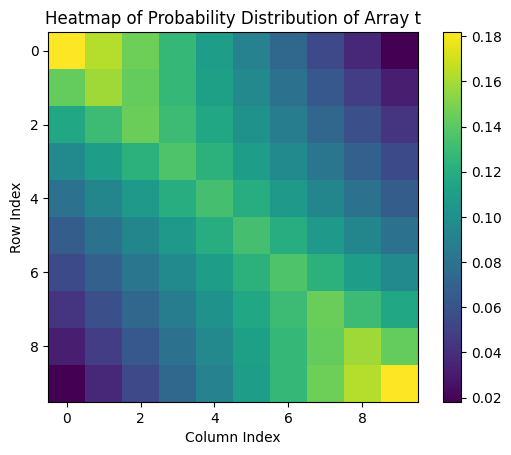

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# 创建一个 32x32 的数组
size = 10
t = np.zeros((size, size))

# 填充数组
for i in range(size):
    for j in range(size):
        t[i, j] = 1 - abs(i - j) * (1 / size)

# 将每一行转换为概率分布
t_prob = t / t.sum(axis=1, keepdims=True)

# 使用热图可视化
plt.imshow(t_prob, cmap='viridis', interpolation='nearest')
plt.colorbar()  # 显示颜色条
plt.title('Heatmap of Probability Distribution of Array t')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()


Temperature: 0.35, Row sums: [1. 1. 1. 1. 1. 1. 1. 1.]


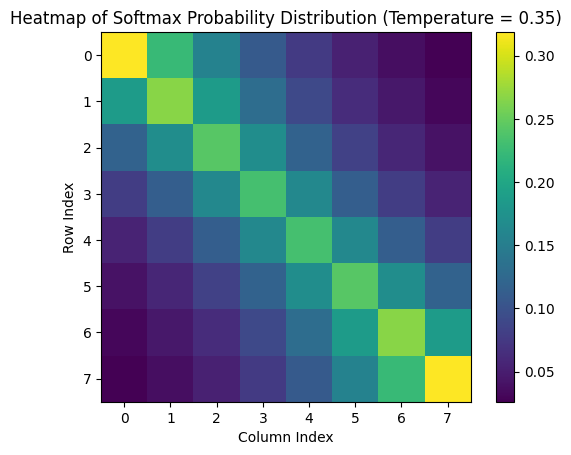

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# 创建一个 32x32 的数组
size = 8
t = np.zeros((size, size))

# 填充数组
for i in range(size):
    for j in range(size):
        t[i, j] = 1 - abs(i - j) * (1 / size)

# 使用 Softmax 函数并调整温度
def softmax(x, temperature=1.0):
    e_x = np.exp(x / temperature - np.max(x / temperature))  # 减去最大值以防止溢出
    return e_x / e_x.sum(axis=1, keepdims=True)

# 设置较低的温度
# temperatures = [0.1, 0.5, 1.0, 2.0]  # 不同的温度值
temp = 0.35
t_prob_softmax = softmax(t, temperature=temp)

# 打印每行的和
print(f"Temperature: {temp}, Row sums: {t_prob_softmax.sum(axis=1)}")

# 使用热图可视化
plt.imshow(t_prob_softmax, cmap='viridis', interpolation='nearest')
plt.colorbar()  # 显示颜色条
plt.title(f'Heatmap of Softmax Probability Distribution (Temperature = {temp})')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

# t_prob_softmax


In [22]:
import numpy as np

def categorical_cross_entropy(y_true, y_pred):
    """
    计算多分类交叉熵损失
    :param y_true: 真实标签（概率分布）
    :param y_pred: 模型预测概率
    :return: 交叉熵损失
    """
    # 确保预测值在 (0, 1) 之间
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return - np.sum(y_true * np.log(y_pred))

# 示例
y_true_multi = np.array([0.1, 0.8, 0.1], dtype=np.float32)  # 真实标签（概率分布）
y_pred_correct_multi = np.array([0.1, 0.8, 0.1], dtype=np.float32)  # 正确预测概率
y_pred_incorrect_multi = np.array([0.6, 0.2, 0.2], dtype=np.float32)  # 错误预测概率

loss_correct_multi = categorical_cross_entropy(y_true_multi, y_pred_correct_multi)
loss_incorrect_multi = categorical_cross_entropy(y_true_multi, y_pred_incorrect_multi)

print(f"正确预测的损失: {loss_correct_multi:.10f}")
print(f"错误预测的损失: {loss_incorrect_multi:.10f}")


正确预测的损失: 0.6390318274
错误预测的损失: 1.4995766878


In [24]:
import numpy as np

def kl_divergence(p, q):
    p = np.clip(p, 1e-10, 1)  # 避免对数中的零
    q = np.clip(q, 1e-10, 1)  # 避免对数中的零
    return np.sum(p * np.log(p / q))

# 示例概率分布
P = np.array([0.1, 0.8, 0.1])  # 真实分布
Q = np.array([0.1, 0.8, 0.1])  # 预测分布

kl_loss = kl_divergence(P, Q)
print(f"KL散度: {kl_loss:.10f}")


KL散度: 0.0000000000


In [25]:
import numpy as np

# 原始数组
arr = np.array([0.8, 0.9, 1, 0.9, 0.8])

# 确保非负性（如果有负数）
arr = np.maximum(arr, 0)

# 归一化
prob_distribution = arr / np.sum(arr)

print("概率分布:", prob_distribution)
print("总和:", np.sum(prob_distribution))  # 应该为1


概率分布: [0.18181818 0.20454545 0.22727273 0.20454545 0.18181818]
总和: 1.0


In [7]:
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABELS = torch.cat([torch.arange(BATCH_SIZE) for i in range(2)], dim=0)
LABELS

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31,  0,  1,  2,  3,
         4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
        22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [8]:
LABELS = (LABELS.unsqueeze(0) == LABELS.unsqueeze(1)).float() # Creates a one-hot with broadcasting
LABELS

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

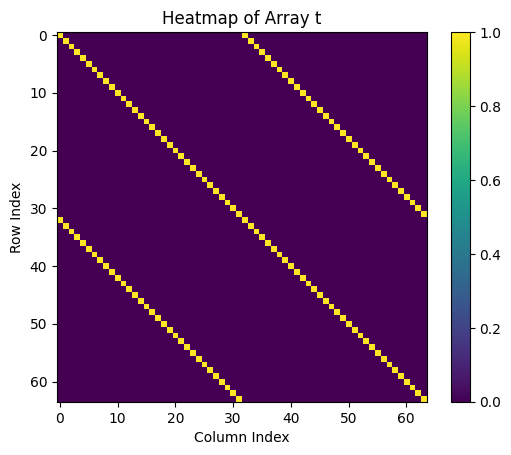

In [9]:
import matplotlib.pyplot as plt
# 使用热图可视化
plt.imshow(LABELS, cmap='viridis', interpolation='nearest')
plt.colorbar()  # 显示颜色条
plt.title('Heatmap of Array t')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()


In [33]:
LABELS = torch.cat([torch.arange(BATCH_SIZE) for i in range(2)], dim=0)
LABELS = (LABELS.unsqueeze(0) == LABELS.unsqueeze(1)).float() # Creates a one-hot with broadcasting
LABELS = LABELS.to(DEVICE) #128,128

features = None
temp = 2
FEATURE_DIM = 128

# 创建随机特征张量，形状为 (BATCH_SIZE, FEATURE_DIM)
features = torch.rand(BATCH_SIZE, FEATURE_DIM).to(DEVICE)

"""
The NTxent Loss.

Args:
    z1: The projection of the first branch
    z2: The projeciton of the second branch

Returns:
    the NTxent loss
"""
similarity_matrix = torch.matmul(features, features.T) # 128, 128
# discard the main diagonal from both: labels and similarities matrix
mask = torch.eye(LABELS.shape[0], dtype=torch.bool).to(DEVICE)
# ~mask is the negative of the mask
# the view is required to bring the matrix back to shape
labels = LABELS[~mask].view(LABELS.shape[0], -1) # 128, 127
similarity_matrix = similarity_matrix[~mask].view(similarity_matrix.shape[0], -1) # 128, 127

# select and combine multiple positives
positives = similarity_matrix[labels.bool()].view(labels.shape[0], -1) # 128, 1

# select only the negatives
negatives = similarity_matrix[~labels.bool()].view(similarity_matrix.shape[0], -1) # 128, 126

logits = torch.cat([positives, negatives], dim=1) # 128, 127
labels = torch.zeros(logits.shape[0], dtype=torch.long).to(DEVICE)

logits = logits / temp


IndexError: The shape of the mask [64, 64] at index 0 does not match the shape of the indexed tensor [32, 32] at index 0

In [38]:
similarity_matrix.shape

torch.Size([32, 32])

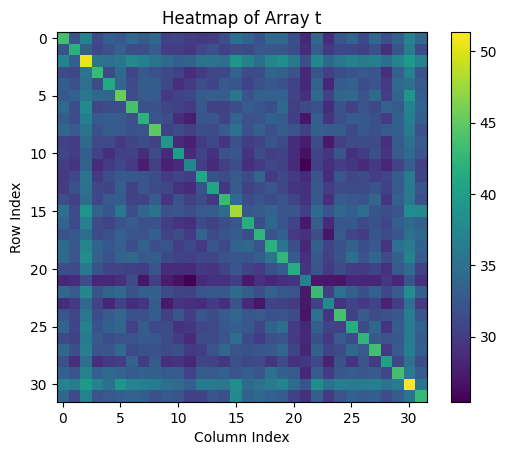

In [36]:
import matplotlib.pyplot as plt
# 使用热图可视化
plt.imshow(similarity_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()  # 显示颜色条
plt.title('Heatmap of Array t')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()
